# AGENTS026 – Hours 2–3: Anomaly Detection & Incident Construction

This notebook builds on the previous data-generation step. It loads the synthetic metrics, logs, Kubernetes-style events, and change events, then implements lightweight anomaly detection using thresholds plus moving averages.

For each detected anomaly window, it samples related logs and events, constructs `IncidentCandidate` objects, stores them in memory and as JSON, and visualizes anomalies with simple plots.


## Section 1 – Imports, Paths, and Data Loading

Load the telemetry files created in the Hours 1–2 notebook.


In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Optional
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
incidents_dir.mkdir(parents=True, exist_ok=True)

metrics_path = data_dir / 'metrics.csv'
logs_path = data_dir / 'app_logs.csv'
k8s_path = data_dir / 'k8s_events.csv'
changes_path = data_dir / 'change_events.csv'

metrics_df = pd.read_csv(metrics_path, parse_dates=['timestamp'])
logs_df = pd.read_csv(logs_path, parse_dates=['timestamp'])
k8s_events_df = pd.read_csv(k8s_path, parse_dates=['timestamp']) if k8s_path.exists() and k8s_path.stat().st_size > 0 else pd.DataFrame(columns=['timestamp','service','type','reason','message'])
changes_df = pd.read_csv(changes_path, parse_dates=['timestamp'])

metrics_df.head()


,timestamp,service,cpu_utilization,rps,latency_p95_ms,error_rate
0,2026-06-10 10:00:00,checkout-api,42.718891,169.410955,105.497667,0.010898
1,2026-06-10 10:01:00,checkout-api,40.837959,197.579256,121.601995,0.010954
2,2026-06-10 10:02:00,checkout-api,43.523207,183.704577,124.724916,0.012124
3,2026-06-10 10:03:00,checkout-api,39.961753,173.039374,113.690241,0.010688
4,2026-06-10 10:04:00,checkout-api,45.427968,188.708788,117.167827,0.010956


## Section 2 – Recreate / Define Core Pydantic Schemas

We re-define the same models here so this notebook can run independently.


In [2]:
from pydantic import BaseModel, Field

class IncidentCandidate(BaseModel):
    incident_id: str
    start_time: datetime
    end_time: datetime
    services: List[str]
    anomaly_type: str
    metric_summary: Dict[str, float] = Field(default_factory=dict)
    log_samples: List[str] = Field(default_factory=list)
    k8s_event_samples: List[str] = Field(default_factory=list)
    change_refs: List[str] = Field(default_factory=list)

class Action(BaseModel):
    action_type: str
    target: str
    parameters: Dict[str, object] = Field(default_factory=dict)
    requires_approval: bool = True
    status: str = 'pending'

class RCAResult(BaseModel):
    incident_id: str
    root_cause_hypothesis: str
    impacted_components: List[str]
    probable_trigger: Optional[str] = None
    evidence: List[str] = Field(default_factory=list)
    confidence: float = Field(..., ge=0.0, le=1.0)


## Section 3 – Moving Average Features & Threshold Rules

We compute moving averages per service and flag anomalies when current values cross simple thresholds or significantly exceed the rolling baseline.

Rules used in this notebook:

- CPU anomaly: `cpu_utilization > 85` or 1.5x above rolling mean.
- Latency anomaly: `latency_p95_ms > 400` or 2x above rolling mean.
- Error-rate anomaly: `error_rate > 0.05` or 2x above rolling mean.


In [3]:
WINDOW = 15  # 15-minute moving window

def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['service', 'timestamp']).copy()
    for metric in ['cpu_utilization', 'latency_p95_ms', 'error_rate', 'rps']:
        df[f'{metric}_ma'] = (
            df.groupby('service')[metric]
              .transform(lambda s: s.rolling(WINDOW, min_periods=5).mean())
        )
    return df

metrics_feat_df = add_rolling_features(metrics_df)
metrics_feat_df.head()


,timestamp,service,cpu_utilization,rps,latency_p95_ms,error_rate,cpu_utilization_ma,latency_p95_ms_ma,error_rate_ma,rps_ma
723,2026-06-10 10:00:00,auth-service,36.727852,83.617629,134.013030,0.012502,NaN,NaN,NaN,NaN
724,2026-06-10 10:01:00,auth-service,40.193500,85.648779,141.117370,0.012076,NaN,NaN,NaN,NaN
725,2026-06-10 10:02:00,auth-service,30.391988,99.335913,139.839897,0.012681,NaN,NaN,NaN,NaN
726,2026-06-10 10:03:00,auth-service,35.337057,78.655667,145.327098,0.011360,NaN,NaN,NaN,NaN
727,2026-06-10 10:04:00,auth-service,38.404985,91.941807,143.881493,0.013667,36.211077,140.835778,0.012457,87.839959


In [4]:
def flag_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['cpu_anomaly'] = (df['cpu_utilization'] > 85) | (df['cpu_utilization'] > 1.5 * df['cpu_utilization_ma'].fillna(df['cpu_utilization']))
    df['latency_anomaly'] = (df['latency_p95_ms'] > 400) | (df['latency_p95_ms'] > 2.0 * df['latency_p95_ms_ma'].fillna(df['latency_p95_ms']))
    df['error_anomaly'] = (df['error_rate'] > 0.05) | (df['error_rate'] > 2.0 * df['error_rate_ma'].fillna(df['error_rate']))
    df['any_anomaly'] = df[['cpu_anomaly', 'latency_anomaly', 'error_anomaly']].any(axis=1)
    return df

anomaly_df = flag_anomalies(metrics_feat_df)
anomaly_df[['service','timestamp','cpu_anomaly','latency_anomaly','error_anomaly','any_anomaly']].head()


,service,timestamp,cpu_anomaly,latency_anomaly,error_anomaly,any_anomaly
723,auth-service,2026-06-10 10:00:00,False,False,False,False
724,auth-service,2026-06-10 10:01:00,False,False,False,False
725,auth-service,2026-06-10 10:02:00,False,False,False,False
726,auth-service,2026-06-10 10:03:00,False,False,False,False
727,auth-service,2026-06-10 10:04:00,False,False,False,False


## Section 4 – Build Anomaly Windows

We group consecutive anomaly points for the same service into anomaly windows. Each window later becomes an `IncidentCandidate`.


In [5]:
def build_anomaly_windows(df: pd.DataFrame, gap_minutes: int = 5) -> List[Dict[str, object]]:
    windows = []
    for service, sdf in df[df['any_anomaly']].sort_values('timestamp').groupby('service'):
        current = None
        prev_ts = None
        for _, row in sdf.iterrows():
            ts = row['timestamp']
            anomaly_types = []
            if row['cpu_anomaly']:
                anomaly_types.append('cpu')
            if row['latency_anomaly']:
                anomaly_types.append('latency')
            if row['error_anomaly']:
                anomaly_types.append('error_rate')

            if current is None:
                current = {
                    'service': service,
                    'start_time': ts,
                    'end_time': ts,
                    'anomaly_types': set(anomaly_types),
                }
            else:
                if prev_ts is not None and (ts - prev_ts) <= pd.Timedelta(minutes=gap_minutes):
                    current['end_time'] = ts
                    current['anomaly_types'].update(anomaly_types)
                else:
                    windows.append(current)
                    current = {
                        'service': service,
                        'start_time': ts,
                        'end_time': ts,
                        'anomaly_types': set(anomaly_types),
                    }
            prev_ts = ts

        if current is not None:
            windows.append(current)

    return windows

anomaly_windows = build_anomaly_windows(anomaly_df, gap_minutes=5)
len(anomaly_windows), anomaly_windows[:5]


(4,
 [{'service': 'catalog-api',
   'start_time': Timestamp('2026-06-10 12:19:00'),
   'end_time': Timestamp('2026-06-10 12:19:00'),
   'anomaly_types': {'error_rate'}},
  {'service': 'catalog-api',
   'start_time': Timestamp('2026-06-10 12:29:00'),
   'end_time': Timestamp('2026-06-10 12:29:00'),
   'anomaly_types': {'error_rate'}},
  {'service': 'catalog-api',
   'start_time': Timestamp('2026-06-10 12:36:00'),
   'end_time': Timestamp('2026-06-10 12:42:00'),
   'anomaly_types': {'error_rate'}},
  {'service': 'catalog-api',
   'start_time': Timestamp('2026-06-10 12:58:00'),
   'end_time': Timestamp('2026-06-10 12:58:00'),
   'anomaly_types': {'error_rate'}}])

## Section 5 – Sample Related Logs, K8s Events, and Change Events

For each anomaly window, collect nearby logs and infrastructure/change events to enrich the incident candidate.


In [6]:
def sample_related_logs(service: str, start_time: pd.Timestamp, end_time: pd.Timestamp, max_samples: int = 8) -> List[str]:
    mask = (logs_df['service'] == service) & (logs_df['timestamp'] >= start_time - pd.Timedelta(minutes=5)) & (logs_df['timestamp'] <= end_time + pd.Timedelta(minutes=5))
    rows = logs_df.loc[mask].sort_values('timestamp').tail(max_samples)
    return [f"{r.timestamp.isoformat()} [{r.level}] {r.message}" for r in rows.itertuples(index=False)]

def sample_related_k8s_events(service: str, start_time: pd.Timestamp, end_time: pd.Timestamp, max_samples: int = 5) -> List[str]:
    if k8s_events_df.empty:
        return []
    mask = (k8s_events_df['service'] == service) & (k8s_events_df['timestamp'] >= start_time - pd.Timedelta(minutes=10)) & (k8s_events_df['timestamp'] <= end_time + pd.Timedelta(minutes=10))
    rows = k8s_events_df.loc[mask].sort_values('timestamp').tail(max_samples)
    return [f"{r.timestamp.isoformat()} [{r.type}/{r.reason}] {r.message}" for r in rows.itertuples(index=False)]

def sample_related_changes(service: str, start_time: pd.Timestamp, end_time: pd.Timestamp, max_samples: int = 5) -> List[str]:
    mask = (changes_df['service'] == service) & (changes_df['timestamp'] >= start_time - pd.Timedelta(minutes=30)) & (changes_df['timestamp'] <= end_time + pd.Timedelta(minutes=10))
    rows = changes_df.loc[mask].sort_values('timestamp').tail(max_samples)
    return [f"{r.timestamp.isoformat()} [{r.change_type}] {r.description} ({r.version})" for r in rows.itertuples(index=False)]


## Section 6 – Construct IncidentCandidate Objects

Convert anomaly windows into structured incident candidates and store them in memory. Also export them to a JSON file so later notebooks can reuse them.


In [7]:
def summarize_window_metrics(service: str, start_time: pd.Timestamp, end_time: pd.Timestamp) -> Dict[str, float]:
    mask = (anomaly_df['service'] == service) & (anomaly_df['timestamp'] >= start_time) & (anomaly_df['timestamp'] <= end_time)
    sdf = anomaly_df.loc[mask]
    if sdf.empty:
        return {}
    return {
        'cpu_max': float(sdf['cpu_utilization'].max()),
        'latency_p95_max': float(sdf['latency_p95_ms'].max()),
        'error_rate_max': float(sdf['error_rate'].max()),
        'rps_avg': float(sdf['rps'].mean()),
    }

incident_candidates: List[IncidentCandidate] = []

for i, win in enumerate(anomaly_windows, start=1):
    service = win['service']
    start_time = pd.Timestamp(win['start_time'])
    end_time = pd.Timestamp(win['end_time'])
    anomaly_type = '+'.join(sorted(win['anomaly_types']))

    candidate = IncidentCandidate(
        incident_id=f'inc-{i:03d}',
        start_time=start_time.to_pydatetime(),
        end_time=end_time.to_pydatetime(),
        services=[service],
        anomaly_type=anomaly_type,
        metric_summary=summarize_window_metrics(service, start_time, end_time),
        log_samples=sample_related_logs(service, start_time, end_time),
        k8s_event_samples=sample_related_k8s_events(service, start_time, end_time),
        change_refs=sample_related_changes(service, start_time, end_time),
    )
    incident_candidates.append(candidate)

len(incident_candidates)


4

In [9]:
# Persist to JSON for later steps
incidents_json_path = incidents_dir / 'incident_candidates.json'
with open(incidents_json_path, 'w', encoding='utf-8') as f:
    json.dump([c.model_dump() for c in incident_candidates], f, default=str, indent=2)

print('Saved incident candidates to:', incidents_json_path)
incident_candidates[0].model_dump() if incident_candidates else 'No incident candidates found'


Saved incident candidates to: /workspace/agents026/data/incidents/incident_candidates.json


{'incident_id': 'inc-001',
 'start_time': datetime.datetime(2026, 6, 10, 12, 19),
 'end_time': datetime.datetime(2026, 6, 10, 12, 19),
 'services': ['catalog-api'],
 'anomaly_type': 'error_rate',
 'metric_summary': {'cpu_max': 26.1119737852507,
  'latency_p95_max': 161.08106122719428,
  'error_rate_max': 0.0032061994146254,
  'rps_avg': 30.86440651983976},
 'log_samples': ['2026-06-10T12:17:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:18:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:19:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:20:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:21:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:22:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:23:00 [INFO] catalog-api handled request batch successfully',
  '2026-06-10T12:24:00 [INFO] catalog-api handled request batch successfu

## Section 7 – Simple Incident Table View

Create a compact tabular view for quick inspection.


In [10]:
incident_rows = []
for c in incident_candidates:
    incident_rows.append({
        'incident_id': c.incident_id,
        'service': ','.join(c.services),
        'anomaly_type': c.anomaly_type,
        'start_time': c.start_time,
        'end_time': c.end_time,
        'cpu_max': c.metric_summary.get('cpu_max'),
        'latency_p95_max': c.metric_summary.get('latency_p95_max'),
        'error_rate_max': c.metric_summary.get('error_rate_max'),
        'log_samples_count': len(c.log_samples),
        'k8s_events_count': len(c.k8s_event_samples),
        'change_refs_count': len(c.change_refs),
    })

incident_table_df = pd.DataFrame(incident_rows)
incident_table_df


,incident_id,service,anomaly_type,start_time,end_time,cpu_max,latency_p95_max,error_rate_max,log_samples_count,k8s_events_count,change_refs_count
0,inc-001,catalog-api,error_rate,2026-06-10 12:19:00,2026-06-10 12:19:00,26.111974,161.081061,0.003206,8,0,2
1,inc-002,catalog-api,error_rate,2026-06-10 12:29:00,2026-06-10 12:29:00,19.477817,158.860977,0.002824,8,0,2
2,inc-003,catalog-api,error_rate,2026-06-10 12:36:00,2026-06-10 12:42:00,24.494021,160.371294,0.004188,8,0,2
3,inc-004,catalog-api,error_rate,2026-06-10 12:58:00,2026-06-10 12:58:00,22.828380,140.693808,0.003110,8,0,0


## Section 8 – Visualize Anomalies

Plot selected service metrics and highlight anomaly points. These plots are useful later in the PPT/demo as supporting evidence.


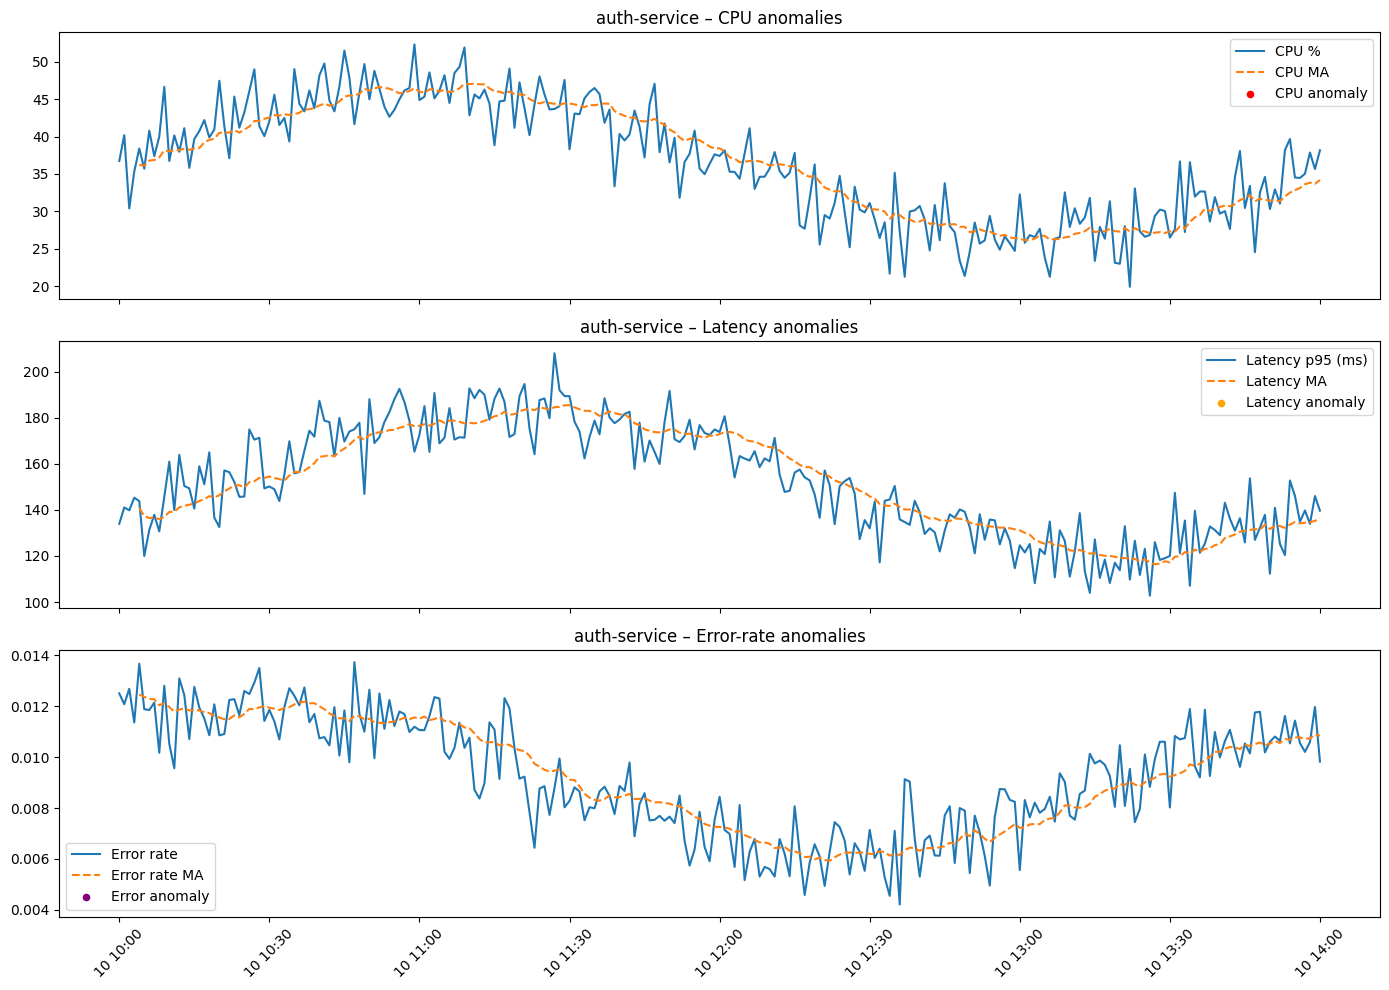

In [11]:
def plot_service_anomalies(service: str):
    sdf = anomaly_df[anomaly_df['service'] == service].sort_values('timestamp').copy()
    if sdf.empty:
        print(f'No data for service: {service}')
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # CPU
    axes[0].plot(sdf['timestamp'], sdf['cpu_utilization'], label='CPU %')
    axes[0].plot(sdf['timestamp'], sdf['cpu_utilization_ma'], label='CPU MA', linestyle='--')
    cpu_anom = sdf[sdf['cpu_anomaly']]
    axes[0].scatter(cpu_anom['timestamp'], cpu_anom['cpu_utilization'], color='red', s=20, label='CPU anomaly')
    axes[0].set_title(f'{service} – CPU anomalies')
    axes[0].legend()

    # Latency
    axes[1].plot(sdf['timestamp'], sdf['latency_p95_ms'], label='Latency p95 (ms)')
    axes[1].plot(sdf['timestamp'], sdf['latency_p95_ms_ma'], label='Latency MA', linestyle='--')
    lat_anom = sdf[sdf['latency_anomaly']]
    axes[1].scatter(lat_anom['timestamp'], lat_anom['latency_p95_ms'], color='orange', s=20, label='Latency anomaly')
    axes[1].set_title(f'{service} – Latency anomalies')
    axes[1].legend()

    # Error rate
    axes[2].plot(sdf['timestamp'], sdf['error_rate'], label='Error rate')
    axes[2].plot(sdf['timestamp'], sdf['error_rate_ma'], label='Error rate MA', linestyle='--')
    err_anom = sdf[sdf['error_anomaly']]
    axes[2].scatter(err_anom['timestamp'], err_anom['error_rate'], color='purple', s=20, label='Error anomaly')
    axes[2].set_title(f'{service} – Error-rate anomalies')
    axes[2].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot first service by default
services = sorted(anomaly_df['service'].unique())
plot_service_anomalies(services[0])


## Section 9 – Inspect One Incident Candidate

Display a single constructed incident candidate in detail to verify that sampled logs, events, and change references look usable for later RCA prompting.


In [12]:
if incident_candidates:
    sample_incident = incident_candidates[0]
    print('Incident ID:', sample_incident.incident_id)
    print('Services:', sample_incident.services)
    print('Anomaly type:', sample_incident.anomaly_type)
    print('Time window:', sample_incident.start_time, '->', sample_incident.end_time)
    print('Metric summary:', sample_incident.metric_summary)
    print('\nLog samples:')
    for x in sample_incident.log_samples[:5]:
        print('-', x)
    print('\nK8s event samples:')
    for x in sample_incident.k8s_event_samples[:5]:
        print('-', x)
    print('\nChange refs:')
    for x in sample_incident.change_refs[:5]:
        print('-', x)
else:
    print('No incident candidates found. Consider adjusting thresholds or regenerating synthetic data with stronger anomalies.')


Incident ID: inc-001
Services: ['catalog-api']
Anomaly type: error_rate
Time window: 2026-06-10 12:19:00 -> 2026-06-10 12:19:00
Metric summary: {'cpu_max': 26.1119737852507, 'latency_p95_max': 161.08106122719428, 'error_rate_max': 0.0032061994146254, 'rps_avg': 30.86440651983976}

Log samples:
- 2026-06-10T12:17:00 [INFO] catalog-api handled request batch successfully
- 2026-06-10T12:18:00 [INFO] catalog-api handled request batch successfully
- 2026-06-10T12:19:00 [INFO] catalog-api handled request batch successfully
- 2026-06-10T12:20:00 [INFO] catalog-api handled request batch successfully
- 2026-06-10T12:21:00 [INFO] catalog-api handled request batch successfully

K8s event samples:

Change refs:
- 2026-06-10T12:13:00 [feature_flag] feature_flag applied to catalog-api at 2026-06-10T12:13:00 (v2.2.2)
- 2026-06-10T12:16:00 [deploy] deploy applied to catalog-api at 2026-06-10T12:16:00 (v2.1.8)
